## **Check Predicted Focal Mechanisms**
### **Only run it AFTER you have finished an evaluation**
### **Only run it when you have PyGMT installed in our environment**

station number: 24


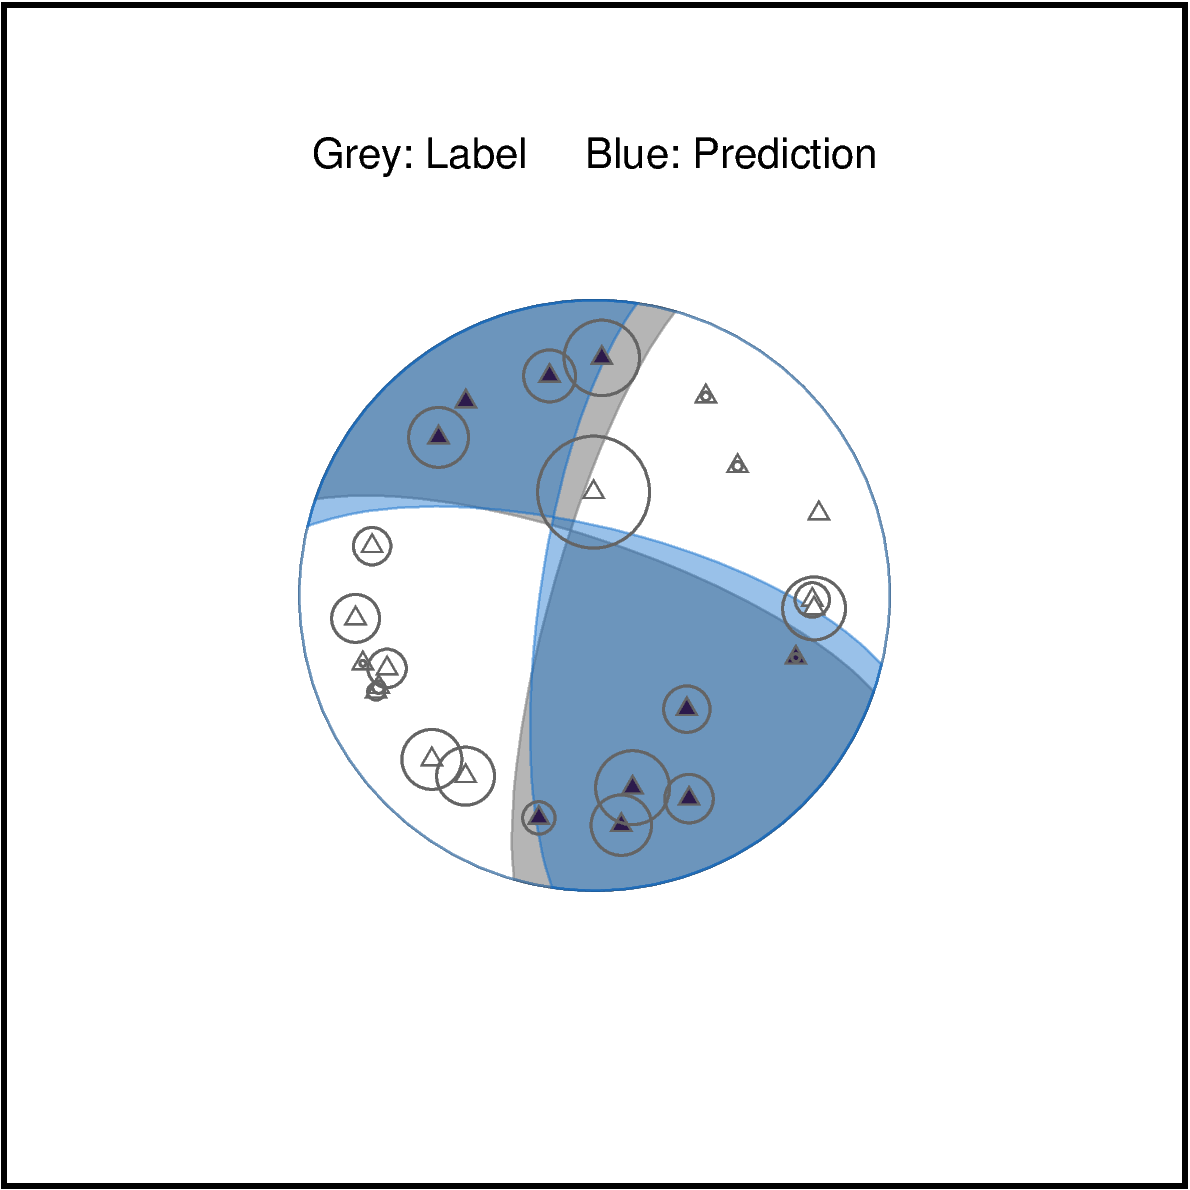

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from pyrocko import moment_tensor as pmt
import config
from obspy.taup import TauPyModel
from obspy.taup import taup_create
from obspy.geodetics import gps2dist_azimuth, kilometer2degrees
from obspy.taup import TauPyModel
import pygmt as gmt

model = TauPyModel(model='Italian_model.npz')


#### CHANGE HERE #################################
# Specify which Earthquake you want to plot? #####
idx = 50
##################################################


data_pol = np.load(config.DEV_DATA, allow_pickle=True).item()
PTs = np.load('dev_outputs.npy')
PTs = PTs.reshape(-1, 3, 3)

eids = list(data_pol.keys())
eid = eids[idx]

focmec0 = data_pol[eid]['focalmech']
stationxyz = data_pol[eid]['stationxyz']
pol_data = data_pol[eid]['polarities']
strike0, dip0, rake0 = focmec0
evdp = float(stationxyz[0, -1])

PT = PTs[idx]
P = PT[0, :]
T = PT[1, :]
moment = pmt.MomentTensor(p_axis=P, t_axis=T)
strike, dip, rake = moment.both_strike_dip_rake()[1]

stations = stationxyz[:, 1:].astype(float)
print('station number:', len(stationxyz[:, 0]))

Xs = stations[:, 0]
Ys = stations[:, 1]
Azs = np.arctan2(Xs, Ys)
Rs = np.sqrt(Xs ** 2 + Ys ** 2)

Xps = []
Yps = []
polarities = []
srps = []

for j in range(len(Xs)):
    path = model.get_ray_paths(source_depth_in_km=evdp, distance_in_degree=kilometer2degrees(Rs[j]), phase_list=['p','P'])
    dx = (path[0].path[1][2] - path[0].path[0][2])*6371
    dy = -(path[0].path[1][3] - path[0].path[0][3])
    take_off = np.arctan2(dx, dy)
    if abs(take_off) < 0.5*np.pi:
        take_off = -take_off
    else:
        take_off = np.pi - take_off

    nx = 1*(take_off)/(0.5*np.pi)*np.sin(Azs[j])
    ny = 1*(take_off)/(0.5*np.pi)*np.cos(Azs[j])

    Xps.append(nx)
    Yps.append(ny)

    pol = pol_data[j, 0]
    SrP = pol_data[j, 7]

    polarities.append(pol)
    srps.append(SrP)

polarities = np.array(polarities)
srps = np.array(srps)

Xps = np.array(Xps)
Yps = np.array(Yps)

fig = gmt.Figure()
focal_mechanism = dict(strike=strike, dip=dip, rake=rake, magnitude=5)
focal_mechanism0 = dict(strike=strike0, dip=dip0, rake=rake0, magnitude=5)
region = [-2, 2, -2, 2]
fig.basemap(region=region, projection="X10c/10c", frame=['blrt'])

fig.meca(spec=focal_mechanism0,scale="5c",longitude=0,latitude=0,depth=10.0,compressionfill="50",pen="0.5p,gray30,solid",outline="0.5p,50,solid", transparency=40)
fig.meca(spec=focal_mechanism,scale="5c",longitude=0,latitude=0,depth=10.0,compressionfill="0/100/200",pen="0.5p,gray30,solid", outline="0.5p,0/100/200,solid", transparency=60)

fig.plot(x = Xps, y=Yps, fill=-polarities[:len(Xps)], style='t0.2c', pen='0.4p,100', cmap='devon')
fig.plot(x = Xps, y=Yps, size = np.clip(srps, 0, 10)*0.25, style='c', pen='0.6p,100')

fig.text(x = 0, y = 1.5, text = 'Grey: Label     Blue: Prediction', font='10p')


fig.savefig('focal.pdf')
fig.show()


## **Result Statistics**
### **Only run it AFTER you have finished an evaluation**

Mean   :12.04
RMS    :14.83
Median :9.88


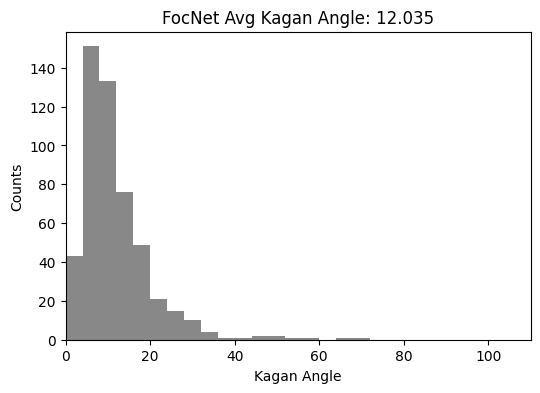

In [1]:
import Kagan
import torch
import matplotlib.pyplot as plt
import pygmt as gmt
import numpy as np
from pyrocko import moment_tensor as pmt
from obspy.taup import TauPyModel
from statistics import median

PTs = np.load('dev_outputs.npy')
PTs = PTs.reshape(-1, 3, 3)
PTs_rf = np.load('dev_referece.npy')
PTs_rf = PTs_rf.reshape(-1, 2, 3)

kagans = Kagan.PTB2Kagan(torch.Tensor(PTs_rf), torch.Tensor(PTs))
kagans *= 180/np.pi
kagans = np.array(kagans)

hist, bin_edges = np.histogram(kagans, np.arange(0, 110, 4), density=False)

x = [bin_edges[0]]
y = [0]
for i in range(len(hist)-1):
    x.append(bin_edges[i])
    x.append(bin_edges[i+1])
    y.append(hist[i])
    y.append(hist[i])
x.append(bin_edges[i])
y.append(0)

data_hist = np.array([x, y]).T

plt.figure(figsize=(6, 4))
plt.bar((bin_edges[0:-1] + bin_edges[1:])/2, hist, width=bin_edges[1] - bin_edges[0], facecolor='#888888')
# plt.plot(x, y)
plt.xlim([0, 110])
plt.xlabel('Kagan Angle')
plt.ylabel('Counts')
plt.title('FocNet Avg Kagan Angle: ' + '%.3f' % float(np.sum(kagans)/len(kagans)))

print('Mean   :%.2f' % np.mean(kagans))
print('RMS    :%.2f' % np.sqrt(np.mean(kagans**2)))
print('Median :%.2f' % median(kagans))


## **Plot Loss Curve**
### **Only run it AFTER the training is finished**

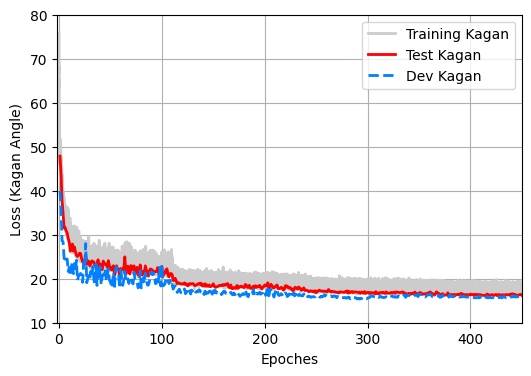

In [2]:
import numpy as np
import matplotlib.pyplot as plt


train_loss = np.loadtxt('train_loss.txt')
test_loss = np.loadtxt('test_loss.txt')
dev_loss = np.loadtxt('dev_loss.txt')

epoch_n = train_loss[-1,0]
iter_n = train_loss[-1,1]

train_x = np.arange(1, epoch_n*iter_n+1)/iter_n # define it based on your need
test_x = np.arange(1, len(test_loss)+1)


fig = plt.figure(figsize=(6, 4))
plt.plot(train_x, train_loss[:, 2], color = [0.8, 0.8, 0.8], linewidth=2)
plt.plot(test_x, test_loss[:, 1], color = [1, 0, 0], linewidth=2)
plt.plot(test_x, dev_loss[:, 1], '--', color = [0, 0.5, 1], linewidth=2)
plt.grid()
plt.ylim([10, 80])
plt.xlim(-2, 450)
plt.xlabel('Epoches')
plt.ylabel('Loss (Kagan Angle)')
plt.legend(['Training Kagan', 'Test Kagan', 'Dev Kagan'])
plt.savefig('loss.pdf')